<a href="https://colab.research.google.com/github/tobiasllop/Tesis/blob/main/Tesis_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# import Libraries
import pandas as pd
import numpy as np
import matplotlib as plt
import pyarrow.parquet as pq
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!pip install jenkspy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.0/642.0 kB 12.6 MB/s eta 0:00:00


# Exploracion de Datos - Sobre CUITS terminados en 0


INICIANDO EXTRACCIÓN Y CLASIFICACIÓN DE MUESTRA (10%)
Cortes BCRA (Miles $): Pequeño<=25,540 | Mediano<150,000
  -> Escaneados: 5,000,000 registros...
  -> Escaneados: 10,000,000 registros...
  -> Escaneados: 15,000,000 registros...
  -> Escaneados: 20,000,000 registros...
  -> Escaneados: 25,000,000 registros...
  -> Escaneados: 30,000,000 registros...
  -> Escaneados: 35,000,000 registros...

Consolidando la muestra en memoria...
Generando gráfico del histograma...


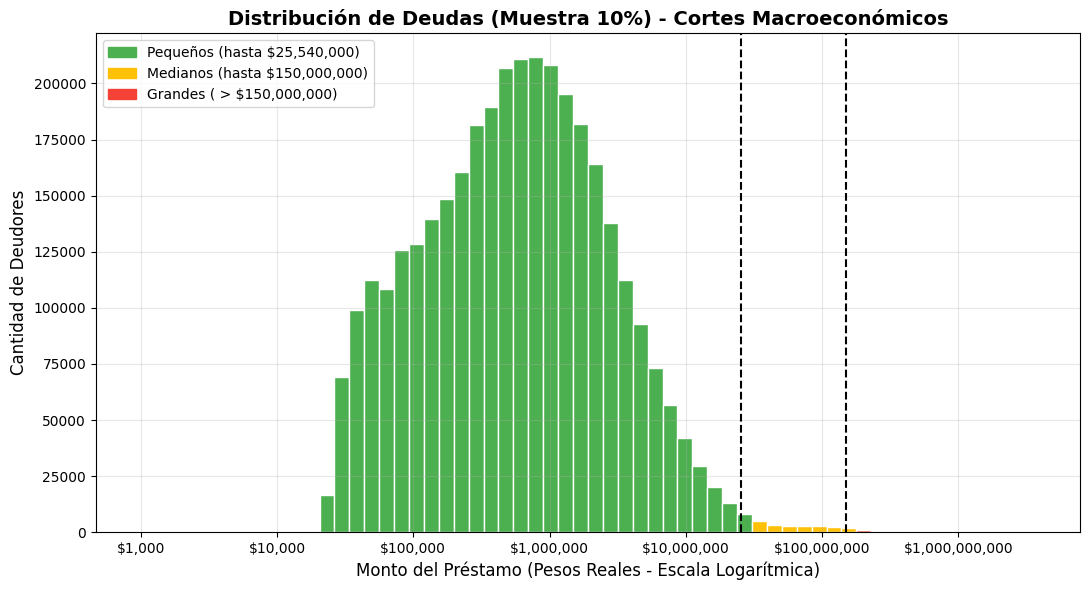

Aplicando clasificación macroeconómica...
Guardando resultados en: /content/drive/MyDrive/Tesis2026/clasificacion_output/muestra_10pct_macro_FINAL.parquet

RESUMEN DE LAS LIGAS PARA EL TORNEO (Nº de Deudas)
segmento
Pequeño      3442150
Sin Deuda     111230
Mediano        24916
Grande          3463
Name: count, dtype: int64
¡PROCESO FINALIZADO!


In [6]:
"""
CLASIFICACIÓN DE DEUDORES (MUESTRA 10% - CRITERIOS MACROECONÓMICOS)
===================================================================
1. Filtra personas físicas cuyo CUIT/CUIL termina en '0'.
2. Grafica el histograma logarítmico coloreando las 3 clases.
3. Clasifica en Pequeña, Mediana o Grande basándose en valores
   reales de la economía (Kwid 0km y Depto 2 Ambientes a 150M).
4. Conserva la columna 'situacion' para la Etapa B (Markov).
"""

import gc
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# CONFIGURACIÓN DE RUTAS Y VARIABLES
# ---------------------------------------------------------
FILE_PATH_RAW = "/content/drive/MyDrive/Tesis2026/deudores_final_enero.parquet"
OUTPUT_DIR    = Path("/content/drive/MyDrive/Tesis2026/clasificacion_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_PATH    = OUTPUT_DIR / "muestra_10pct_macro_FINAL.parquet"

PREFIJOS_FISICAS = ("20", "23", "24", "27")
BATCH_SIZE       = 100_000

# ---------------------------------------------------------
# CRITERIOS MACROECONÓMICOS (En pesos reales)
# ---------------------------------------------------------
VALOR_RENAULT_KWID = 25540000    # $25.540.000
VALOR_DEPTO_2AMB   = 150000000   # $150.000.000

# El BCRA reporta en miles de pesos. Ajustamos la escala internamente:
CORTE_PEQUENO = VALOR_RENAULT_KWID / 1000
CORTE_MEDIANO = VALOR_DEPTO_2AMB / 1000

def asignar_clase_macro(deuda):
    if deuda <= 0: return "Sin Deuda"
    if deuda <= CORTE_PEQUENO: return "Pequeño"
    if deuda < CORTE_MEDIANO: return "Mediano"
    return "Grande"

def graficar_histograma_macro(datos, corte_peq, corte_med):
    print("Generando gráfico del histograma...")
    datos_activos = datos[datos > 0]

    log_deuda = np.log10(datos_activos)
    log_c1 = np.log10(corte_peq)
    log_c2 = np.log10(corte_med)

    plt.figure(figsize=(11, 6))
    n, bins, patches = plt.hist(log_deuda, bins=60, color='#B0BEC5', edgecolor='white')

    for val, patch in zip(bins, patches):
        if val <= log_c1:   patch.set_facecolor('#4CAF50') # Verde: Pequeños
        elif val <= log_c2: patch.set_facecolor('#FFC107') # Amarillo: Medianos
        else:               patch.set_facecolor('#F44336') # Rojo: Grandes

    plt.axvline(log_c1, color='black', linestyle='dashed', linewidth=1.5)
    plt.axvline(log_c2, color='black', linestyle='dashed', linewidth=1.5)

    plt.title('Distribución de Deudas (Muestra 10%) - Cortes Macroeconómicos', fontsize=14, fontweight='bold')
    plt.xlabel('Monto del Préstamo (Pesos Reales - Escala Logarítmica)', fontsize=12)
    plt.ylabel('Cantidad de Deudores', fontsize=12)

    plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"${(10**x)*1000:,.0f}"))

    plt.legend(handles=[
        mpatches.Patch(color='#4CAF50', label=f'Pequeños (hasta ${VALOR_RENAULT_KWID:,.0f})'),
        mpatches.Patch(color='#FFC107', label=f'Medianos (hasta ${VALOR_DEPTO_2AMB:,.0f})'),
        mpatches.Patch(color='#F44336', label=f'Grandes ( > ${VALOR_DEPTO_2AMB:,.0f})')
    ])

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "histograma_macro.png", dpi=150)
    plt.show()

# ---------------------------------------------------------
# PROCESAMIENTO DE LA MUESTRA
# ---------------------------------------------------------
def procesar_muestra_macro():
    print("="*60)
    print("INICIANDO EXTRACCIÓN Y CLASIFICACIÓN DE MUESTRA (10%)")
    print("="*60)
    print(f"Cortes BCRA (Miles $): Pequeño<={CORTE_PEQUENO:,.0f} | Mediano<{CORTE_MEDIANO:,.0f}")

    lista_chunks = []
    total_leidos = 0

    cols = ["cod_entidad", "tipo_id", "nro_id", "prestamos", "situacion"]

    for batch in pq.ParquetFile(FILE_PATH_RAW).iter_batches(batch_size=BATCH_SIZE, columns=cols):
        df = batch.to_pandas()
        total_leidos += len(df)

        df["tipo_id"] = df["tipo_id"].astype(str)
        df["nro_id"]  = df["nro_id"].astype(str)

        mask = (
            (df["tipo_id"] == "11") &
            df["nro_id"].str.startswith(PREFIJOS_FISICAS) &
            df["nro_id"].str.endswith("0")
        )

        # Traemos también la columna situacion
        muestra_filtrada = df.loc[mask, ["cod_entidad", "nro_id", "prestamos", "situacion"]].copy()
        del df; gc.collect()

        if not muestra_filtrada.empty:
            muestra_filtrada["prestamos"] = pd.to_numeric(muestra_filtrada["prestamos"], errors="coerce").fillna(0)
            # Nos aseguramos de que la situación sea un número entero (1 a 6)
            muestra_filtrada["situacion"] = pd.to_numeric(muestra_filtrada["situacion"], errors="coerce").fillna(1).astype(int)
            lista_chunks.append(muestra_filtrada)

        if total_leidos % 5_000_000 == 0:
            print(f"  -> Escaneados: {total_leidos:,} registros...")

    print("\nConsolidando la muestra en memoria...")
    df_final = pd.concat(lista_chunks, ignore_index=True)
    del lista_chunks; gc.collect()

    df_final = df_final.rename(columns={"prestamos": "deuda_total"})

    graficar_histograma_macro(df_final["deuda_total"], CORTE_PEQUENO, CORTE_MEDIANO)

    print("Aplicando clasificación macroeconómica...")
    df_final["segmento"] = df_final["deuda_total"].apply(asignar_clase_macro)

    # Reordenamos las columnas para que quede prolijo
    df_final = df_final[["cod_entidad", "nro_id", "deuda_total", "segmento", "situacion"]]

    print(f"Guardando resultados en: {FINAL_PATH}")
    table = pa.Table.from_pandas(df_final)
    pq.write_table(table, str(FINAL_PATH))

    conteo = df_final["segmento"].value_counts()
    print("\n" + "="*60)
    print("RESUMEN DE LAS LIGAS PARA EL TORNEO (Nº de Deudas)")
    print("="*60)
    print(conteo)
    print("="*60)
    print("¡PROCESO FINALIZADO!")

if __name__ == "__main__":
    procesar_muestra_macro()

In [8]:
import pandas as pd
import pyarrow.parquet as pq

print("Cargando la base clasificada...")
# Cargar tu muestra (asegurate de que la ruta sea la correcta)
df = pq.read_table("/content/drive/MyDrive/Tesis2026/clasificacion_output/muestra_10pct_macro_FINAL.parquet").to_pandas()

# 1. AGRUPACIÓN ESTRICTA
# Al agrupar por nro_id, segmento y situacion, garantizamos que las entidades
# compitan en EXCELENTE IGUALDAD DE CONDICIONES (Misma persona, misma clase de deuda, misma sit).
conteo_bancos = df.groupby(['nro_id', 'segmento', 'situacion']).size().reset_index(name='num_entidades')

# 2. FILTRO DE PARTIDOS
# Si la persona tiene 1 sola entidad bajo esas condiciones exactas, no hay partido.
# Necesitamos mínimo 2.
partidos_validos = conteo_bancos[conteo_bancos['num_entidades'] >= 2].copy()

# 3. CÁLCULO DE COMBINACIONES
# Si le debe a 2 bancos iguales -> 1 partido.
# Si le debe a 3 bancos iguales -> 3 partidos (A vs B, A vs C, B vs C). Formula: N * (N - 1) / 2
partidos_validos['partidos_posibles'] = (partidos_validos['num_entidades'] * (partidos_validos['num_entidades'] - 1)) / 2

# 4. REPORTE DESGLOSADO PARA LA TESIS
# Agrupamos los resultados para ver dónde se juegan más partidos
reporte = partidos_validos.groupby(['segmento', 'situacion'])['partidos_posibles'].sum().reset_index()

# Ordenamos para que quede prolijo
reporte = reporte.sort_values(by=['segmento', 'situacion'])
reporte['partidos_posibles'] = reporte['partidos_posibles'].astype(int)

print("\n" + "="*60)
print("PARTIDOS POTENCIALES ESTRICTOS (Misma Liga, Misma Situación)")
print("="*60)
# Formateamos la salida para que sea fácil de leer
for index, row in reporte.iterrows():
    print(f"Liga: {row['segmento']:<10} | Situación Inicial: {row['situacion']} | Partidos: {row['partidos_posibles']:,}")
print("-" * 60)
print(f"Total global de partidos a jugar: {reporte['partidos_posibles'].sum():,.0f}")
print("="*60)

# Dato de color para la tesis: ¿Cuántas personas únicas van a "arbitrar" estos partidos?
arbitros_unicos = partidos_validos['nro_id'].nunique()
print(f"\nDeudores únicos que participan en al menos un partido: {arbitros_unicos:,}")

Cargando la base clasificada...

PARTIDOS POTENCIALES ESTRICTOS (Misma Liga, Misma Situación)
Liga: Grande     | Situación Inicial: 1 | Partidos: 428
Liga: Grande     | Situación Inicial: 2 | Partidos: 1
Liga: Grande     | Situación Inicial: 3 | Partidos: 7
Liga: Grande     | Situación Inicial: 4 | Partidos: 5
Liga: Mediano    | Situación Inicial: 1 | Partidos: 1,312
Liga: Mediano    | Situación Inicial: 2 | Partidos: 57
Liga: Mediano    | Situación Inicial: 3 | Partidos: 91
Liga: Mediano    | Situación Inicial: 4 | Partidos: 112
Liga: Mediano    | Situación Inicial: 5 | Partidos: 2
Liga: Pequeño    | Situación Inicial: 1 | Partidos: 1,806,612
Liga: Pequeño    | Situación Inicial: 2 | Partidos: 32,436
Liga: Pequeño    | Situación Inicial: 3 | Partidos: 54,681
Liga: Pequeño    | Situación Inicial: 4 | Partidos: 96,940
Liga: Pequeño    | Situación Inicial: 5 | Partidos: 99,141
Liga: Pequeño    | Situación Inicial: 11 | Partidos: 1
Liga: Sin Deuda  | Situación Inicial: 5 | Partidos: 9,262

# Clasificacion sobre el Total

In [9]:
"""
CLASIFICACIÓN DE DEUDORES (POBLACIÓN TOTAL - CRITERIOS MACRO)
=============================================================
1. Procesa TODO el archivo leyendo y escribiendo por lotes (streaming).
2. Filtra personas físicas (tipo_id == 11 y prefijos válidos).
3. NUEVO FILTRO: Solo deudores en situación 1, 2 o 3.
4. Clasifica en Pequeña, Mediana o Grande según valores macroeconómicos.
"""

import gc
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# CONFIGURACIÓN DE RUTAS Y VARIABLES
# ---------------------------------------------------------
FILE_PATH_RAW = "/content/drive/MyDrive/Tesis2026/deudores_final_enero.parquet"
OUTPUT_DIR    = Path("/content/drive/MyDrive/Tesis2026/clasificacion_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FINAL_PATH    = OUTPUT_DIR / "poblacion_total_macro_sit123_FINAL.parquet"

PREFIJOS_FISICAS = ("20", "23", "24", "27")
BATCH_SIZE       = 100_000

# ---------------------------------------------------------
# CRITERIOS MACROECONÓMICOS (En pesos reales)
# ---------------------------------------------------------
VALOR_RENAULT_KWID = 25540000    # $25.540.000
VALOR_DEPTO_2AMB   = 150000000   # $150.000.000

# Ajuste a la escala del BCRA (miles de pesos)
CORTE_PEQUENO = VALOR_RENAULT_KWID / 1000
CORTE_MEDIANO = VALOR_DEPTO_2AMB / 1000

def asignar_clase_macro(deuda):
    if deuda <= 0: return "Sin Deuda"
    if deuda <= CORTE_PEQUENO: return "Pequeño"
    if deuda < CORTE_MEDIANO: return "Mediano"
    return "Grande"

# ---------------------------------------------------------
# PROCESAMIENTO MASIVO (STREAMING)
# ---------------------------------------------------------
def procesar_poblacion_total():
    print("="*60)
    print("INICIANDO CLASIFICACIÓN DE POBLACIÓN TOTAL (SIT 1, 2 y 3)")
    print("="*60)

    # Definimos el esquema del archivo de salida
    schema_out = pa.schema([
        pa.field("cod_entidad", pa.string()),
        pa.field("nro_id", pa.string()),
        pa.field("deuda_total", pa.float64()),
        pa.field("segmento", pa.string()),
        pa.field("situacion", pa.int32())
    ])

    writer = pq.ParquetWriter(str(FINAL_PATH), schema=schema_out)

    cols = ["cod_entidad", "tipo_id", "nro_id", "prestamos", "situacion"]

    total_leidos = 0
    total_guardados = 0
    conteo_segmentos = {"Pequeño": 0, "Mediano": 0, "Grande": 0, "Sin Deuda": 0}

    for batch in pq.ParquetFile(FILE_PATH_RAW).iter_batches(batch_size=BATCH_SIZE, columns=cols):
        df = batch.to_pandas()
        total_leidos += len(df)

        # Formateo inicial para poder filtrar bien
        df["tipo_id"] = df["tipo_id"].astype(str)
        df["nro_id"]  = df["nro_id"].astype(str)
        df["situacion"] = pd.to_numeric(df["situacion"], errors="coerce").fillna(1).astype(int)

        # Filtro: Físicas Y que la situación esté en [1, 2, 3]
        mask = (
            (df["tipo_id"] == "11") &
            df["nro_id"].str.startswith(PREFIJOS_FISICAS) &
            (df["situacion"].isin([1, 2, 3]))
        )

        chunk = df.loc[mask, ["cod_entidad", "nro_id", "prestamos", "situacion"]].copy()
        del df; gc.collect()

        if not chunk.empty:
            chunk["prestamos"] = pd.to_numeric(chunk["prestamos"], errors="coerce").fillna(0)
            chunk = chunk.rename(columns={"prestamos": "deuda_total"})

            # Clasificamos
            chunk["segmento"] = chunk["deuda_total"].apply(asignar_clase_macro)

            # Escribimos directo al disco
            table = pa.Table.from_pandas(chunk, schema=schema_out, preserve_index=False)
            writer.write_table(table)

            # Actualizamos contadores
            total_guardados += len(chunk)
            for seg, count in chunk["segmento"].value_counts().items():
                conteo_segmentos[seg] += count

        if total_leidos % 5_000_000 == 0:
            print(f"  -> Escaneados: {total_leidos:>10,} | Retenidos (Sit 1-3): {total_guardados:>10,}")

    writer.close()

    print("\n" + "="*60)
    print("RESUMEN DE LAS LIGAS PARA EL TORNEO (Población Total)")
    print("="*60)
    for seg, count in conteo_segmentos.items():
        print(f"  {seg:<10}: {count:>12,}")
    print("="*60)
    print(f"✓ Archivo final guardado en: {FINAL_PATH}")
    print("¡PROCESO FINALIZADO!")

if __name__ == "__main__":
    procesar_poblacion_total()

INICIANDO CLASIFICACIÓN DE POBLACIÓN TOTAL (SIT 1, 2 y 3)
  -> Escaneados:  5,000,000 | Retenidos (Sit 1-3):  4,248,638
  -> Escaneados: 10,000,000 | Retenidos (Sit 1-3):  8,718,495
  -> Escaneados: 15,000,000 | Retenidos (Sit 1-3): 13,231,822
  -> Escaneados: 20,000,000 | Retenidos (Sit 1-3): 17,645,907
  -> Escaneados: 25,000,000 | Retenidos (Sit 1-3): 20,664,578
  -> Escaneados: 30,000,000 | Retenidos (Sit 1-3): 24,090,040
  -> Escaneados: 35,000,000 | Retenidos (Sit 1-3): 28,284,238

RESUMEN DE LAS LIGAS PARA EL TORNEO (Población Total)
  Pequeño   :   32,337,837
  Mediano   :      255,124
  Grande    :       37,084
  Sin Deuda :       12,222
✓ Archivo final guardado en: /content/drive/MyDrive/Tesis2026/clasificacion_output/poblacion_total_macro_sit123_FINAL.parquet
¡PROCESO FINALIZADO!


In [11]:
import pandas as pd
import pyarrow.parquet as pq

print("Cargando la base clasificada...")
# Cargar tu muestra (asegurate de que la ruta sea la correcta)
df = pq.read_table("/content/drive/MyDrive/Tesis2026/clasificacion_output/poblacion_total_macro_sit123_FINAL.parquet").to_pandas()

# 1. AGRUPACIÓN ESTRICTA
# Al agrupar por nro_id, segmento y situacion, garantizamos que las entidades
# compitan en EXCELENTE IGUALDAD DE CONDICIONES (Misma persona, misma clase de deuda, misma sit).
conteo_bancos = df.groupby(['nro_id', 'segmento', 'situacion']).size().reset_index(name='num_entidades')

# 2. FILTRO DE PARTIDOS
# Si la persona tiene 1 sola entidad bajo esas condiciones exactas, no hay partido.
# Necesitamos mínimo 2.
partidos_validos = conteo_bancos[conteo_bancos['num_entidades'] >= 2].copy()

# 3. CÁLCULO DE COMBINACIONES
# Si le debe a 2 bancos iguales -> 1 partido.
# Si le debe a 3 bancos iguales -> 3 partidos (A vs B, A vs C, B vs C). Formula: N * (N - 1) / 2
partidos_validos['partidos_posibles'] = (partidos_validos['num_entidades'] * (partidos_validos['num_entidades'] - 1)) / 2

# 4. REPORTE DESGLOSADO PARA LA TESIS
# Agrupamos los resultados para ver dónde se juegan más partidos
reporte = partidos_validos.groupby(['segmento', 'situacion'])['partidos_posibles'].sum().reset_index()

# Ordenamos para que quede prolijo
reporte = reporte.sort_values(by=['segmento', 'situacion'])
reporte['partidos_posibles'] = reporte['partidos_posibles'].astype(int)

print("\n" + "="*60)
print("PARTIDOS POTENCIALES ESTRICTOS (Misma Liga, Misma Situación)")
print("="*60)
# Formateamos la salida para que sea fácil de leer
for index, row in reporte.iterrows():
    print(f"Liga: {row['segmento']:<10} | Situación Inicial: {row['situacion']} | Partidos: {row['partidos_posibles']:,}")
print("-" * 60)
print(f"Total global de partidos a jugar: {reporte['partidos_posibles'].sum():,.0f}")
print("="*60)

# Dato de color para la tesis: ¿Cuántas personas únicas van a "arbitrar" estos partidos?
arbitros_unicos = partidos_validos['nro_id'].nunique()
print(f"\nDeudores únicos que participan en al menos un partido: {arbitros_unicos:,}")

Cargando la base clasificada...

PARTIDOS POTENCIALES ESTRICTOS (Misma Liga, Misma Situación)
Liga: Grande     | Situación Inicial: 1 | Partidos: 4,327
Liga: Grande     | Situación Inicial: 2 | Partidos: 52
Liga: Grande     | Situación Inicial: 3 | Partidos: 67
Liga: Mediano    | Situación Inicial: 1 | Partidos: 13,655
Liga: Mediano    | Situación Inicial: 2 | Partidos: 676
Liga: Mediano    | Situación Inicial: 3 | Partidos: 1,168
Liga: Pequeño    | Situación Inicial: 1 | Partidos: 19,885,403
Liga: Pequeño    | Situación Inicial: 2 | Partidos: 358,866
Liga: Pequeño    | Situación Inicial: 3 | Partidos: 599,992
------------------------------------------------------------
Total global de partidos a jugar: 20,864,206

Deudores únicos que participan en al menos un partido: 7,684,226


In [12]:
print(df.head())

  cod_entidad       nro_id  deuda_total segmento  situacion
0       00007  20018217733        991.0  Pequeño          1
1       00007  20003932118        297.0  Pequeño          1
2       00007  20005966516       1224.0  Pequeño          1
3       00007  20040941607       1262.0  Pequeño          1
4       00007  20040986805       2879.0  Pequeño          3


### Cargamos Base Febrero

In [1]:
"""
CELDA 1: ARMADO DE BASE CRUZADA (ENERO + FEBRERO)
=================================================
1. Carga Enero y aísla solo a los "Árbitros" (clientes con >= 2 entidades en igual sit/liga).
2. Va a buscar a esos deudores específicos a la base de Febrero.
3. Cruza la información (LEFT JOIN para detectar deudas pagadas).
4. Guarda un archivo intermedio con el cruce.
"""

import gc
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# --- RUTAS DE ARCHIVOS ---
JAN_PATH = "/content/drive/MyDrive/Tesis2026/clasificacion_output/poblacion_total_macro_sit123_FINAL.parquet"
FEB_PATH = "/content/drive/MyDrive/Tesis2026/deudores_final_febrero.parquet"
OUTPUT_DIR = Path("/content/drive/MyDrive/Tesis2026/clasificacion_output")
CRUCE_PATH = OUTPUT_DIR / "base_cruce_enero_febrero.parquet"

BATCH_SIZE = 500_000

print("="*60)
print("1. LEYENDO ENERO Y ARMANDO EL ROSTER DE ÁRBITROS")
print("="*60)

# Cargar Enero
df_jan = pq.read_table(JAN_PATH).to_pandas()
df_jan = df_jan.rename(columns={"deuda_total": "deuda_enero", "situacion": "situacion_enero"})

# Buscar a los deudores viables (>= 2 bancos en igual segmento y situacion)
conteo = df_jan.groupby(['nro_id', 'segmento', 'situacion_enero']).size().reset_index(name='n_entidades')
grupos_validos = conteo[conteo['n_entidades'] >= 2]

# Filtramos la base de enero para quedarnos solo con la gente que puede jugar partidos
df_jan_tourney = pd.merge(df_jan, grupos_validos[['nro_id', 'segmento', 'situacion_enero']],
                          on=['nro_id', 'segmento', 'situacion_enero'], how='inner')

arbitros_validos = set(df_jan_tourney['nro_id'].unique())
print(f" -> Deudores multi-banco habilitados para arbitrar: {len(arbitros_validos):,}")

del df_jan, conteo, grupos_validos; gc.collect()

print("\n" + "="*60)
print("2. LEYENDO FEBRERO Y EXTRAYENDO ÁRBITROS")
print("="*60)

feb_cols = ["cod_entidad", "tipo_id", "nro_id", "prestamos", "situacion"]
feb_chunks = []
total_leidos = 0

for batch in pq.ParquetFile(FEB_PATH).iter_batches(batch_size=BATCH_SIZE, columns=feb_cols):
    df_feb = batch.to_pandas()
    total_leidos += len(df_feb)

    df_feb["tipo_id"] = df_feb["tipo_id"].astype(str)
    df_feb["nro_id"]  = df_feb["nro_id"].astype(str)

    # Filtro: Físicas Y que estén en nuestro set de árbitros
    mask = (df_feb["tipo_id"] == "11") & (df_feb["nro_id"].isin(arbitros_validos))
    chunk = df_feb.loc[mask].copy()

    if not chunk.empty:
        chunk["prestamos"] = pd.to_numeric(chunk["prestamos"], errors="coerce").fillna(0)
        chunk["situacion"] = pd.to_numeric(chunk["situacion"], errors="coerce").fillna(1).astype(int)

        # Agrupamos por si hay duplicados
        chunk_agg = chunk.groupby(["cod_entidad", "nro_id"], as_index=False).agg(
            deuda_febrero=("prestamos", "sum"),
            situacion_febrero=("situacion", "max")
        )
        feb_chunks.append(chunk_agg)

    del df_feb, chunk; gc.collect()
    if total_leidos % 10_000_000 == 0:
        print(f"  -> {total_leidos:,} registros de Febrero escaneados...")

# Unimos todo Febrero
df_feb_full = pd.concat(feb_chunks, ignore_index=True)
df_feb_full = df_feb_full.groupby(["cod_entidad", "nro_id"], as_index=False).agg(
    deuda_febrero=("deuda_febrero", "sum"),
    situacion_febrero=("situacion_febrero", "max")
)
del feb_chunks; gc.collect()

print("\n" + "="*60)
print("3. CRUZANDO MESES Y GUARDANDO BASE INTERMEDIA")
print("="*60)

# LEFT JOIN: Mantenemos el roster de Enero. Si no está en Febrero, asume que pagó (Deuda 0, Sit 1).
df_cruce = pd.merge(df_jan_tourney, df_feb_full, on=["cod_entidad", "nro_id"], how="left")
df_cruce['deuda_febrero'] = df_cruce['deuda_febrero'].fillna(0)
df_cruce['situacion_febrero'] = df_cruce['situacion_febrero'].fillna(1).astype(int)

# Guardar base intermedia
table = pa.Table.from_pandas(df_cruce)
pq.write_table(table, str(CRUCE_PATH))

print(f"✓ Base cruzada guardada exitosamente en: {CRUCE_PATH}")
del df_jan_tourney, df_feb_full, df_cruce; gc.collect()

1. LEYENDO ENERO Y ARMANDO EL ROSTER DE ÁRBITROS
 -> Deudores multi-banco habilitados para arbitrar: 7,684,226

2. LEYENDO FEBRERO Y EXTRAYENDO ÁRBITROS
  -> 10,000,000 registros de Febrero escaneados...
  -> 20,000,000 registros de Febrero escaneados...
  -> 30,000,000 registros de Febrero escaneados...
  -> 40,000,000 registros de Febrero escaneados...

3. CRUZANDO MESES Y GUARDANDO BASE INTERMEDIA
✓ Base cruzada guardada exitosamente en: /content/drive/MyDrive/Tesis2026/clasificacion_output/base_cruce_enero_febrero.parquet


9

In [2]:
"""
CELDA 2 OPTIMIZADA: PARTIDOS Y DESEMPATES POR LOTES (CHUNKED)
=============================================================
Estrategia: Evitar la explosión de RAM del Self-Join procesando
a los deudores (árbitros) en pequeños lotes, guardando los
resultados progresivamente en disco.
"""

import gc
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# --- RUTAS DE ARCHIVOS ---
OUTPUT_DIR = Path("/content/drive/MyDrive/Tesis2026/clasificacion_output")
CRUCE_PATH = OUTPUT_DIR / "base_cruce_enero_febrero.parquet"
FINAL_MARKOV_PATH = OUTPUT_DIR / "base_markov_partidos_desempatados.parquet"

# Cantidad de "árbitros" a procesar por ciclo (Bajalo si Colab sigue llorando)
CHUNK_SIZE = 50_000

print("="*60)
print("1. CARGANDO BASE CRUZADA Y ARMANDO LOTES")
print("="*60)

# Cargar la base (suele entrar bien en RAM, lo que explota es el merge posterior)
df_cruce = pq.read_table(CRUCE_PATH).to_pandas()

# Extraer a los deudores únicos para dividirlos en lotes
arbitros_unicos = df_cruce['nro_id'].unique()
total_arbitros = len(arbitros_unicos)
print(f"Total de deudores (árbitros) a procesar: {total_arbitros:,}")

print("\n" + "="*60)
print("2. JUGANDO PARTIDOS POR LOTES (Sin saturar RAM)")
print("="*60)

# Esquema estricto para ir escribiendo de a pedazos
schema_final = pa.schema([
    pa.field("cod_entidad", pa.string()),
    pa.field("nro_id", pa.string()),
    pa.field("deuda_enero", pa.float64()),
    pa.field("segmento", pa.string()),
    pa.field("situacion_enero", pa.int32()),
    pa.field("deuda_febrero", pa.float64()),
    pa.field("situacion_febrero", pa.int32())
])

writer = pq.ParquetWriter(str(FINAL_MARKOV_PATH), schema=schema_final)

reporte_lotes = []
total_partidos_validos = 0

# Procesamos iterando sobre los árbitros en porciones manejables
for i in range(0, total_arbitros, CHUNK_SIZE):
    lote_ids = arbitros_unicos[i : i + CHUNK_SIZE]

    # Filtramos la base solo para los deudores de este turno
    df_lote = df_cruce[df_cruce['nro_id'].isin(lote_ids)]

    # Self-join seguro (es pequeño, no explota la RAM)
    partidos = pd.merge(
        df_lote, df_lote,
        on=['nro_id', 'segmento', 'situacion_enero'],
        suffixes=('_A', '_B')
    )

    # Filtros de torneo
    partidos = partidos[partidos['cod_entidad_A'] < partidos['cod_entidad_B']]
    partidos_validos = partidos[partidos['situacion_febrero_A'] != partidos['situacion_febrero_B']]

    if not partidos_validos.empty:
        # Guardar estadísticas del lote
        rep = partidos_validos.groupby(['segmento', 'situacion_enero']).size().reset_index(name='partidos')
        reporte_lotes.append(rep)
        total_partidos_validos += len(partidos_validos)

        # Aislar entidades y clientes que realmente jugaron partidos válidos
        ent_A = partidos_validos[['nro_id', 'cod_entidad_A']].rename(columns={'cod_entidad_A': 'cod_entidad'})
        ent_B = partidos_validos[['nro_id', 'cod_entidad_B']].rename(columns={'cod_entidad_B': 'cod_entidad'})
        entidades_activas = pd.concat([ent_A, ent_B]).drop_duplicates()

        # Cruzar con la base del lote para tener los datos limpios
        base_final_lote = pd.merge(df_lote, entidades_activas, on=['nro_id', 'cod_entidad'], how='inner')
        base_final_lote = base_final_lote[["cod_entidad", "nro_id", "deuda_enero", "segmento", "situacion_enero", "deuda_febrero", "situacion_febrero"]]

        # Asegurar tipos de datos para PyArrow
        base_final_lote["situacion_enero"] = base_final_lote["situacion_enero"].astype('int32')
        base_final_lote["situacion_febrero"] = base_final_lote["situacion_febrero"].astype('int32')
        base_final_lote["deuda_enero"] = base_final_lote["deuda_enero"].astype('float64')
        base_final_lote["deuda_febrero"] = base_final_lote["deuda_febrero"].astype('float64')

        # Escribir el lote en el disco
        table = pa.Table.from_pandas(base_final_lote, schema=schema_final, preserve_index=False)
        writer.write_table(table)

    # Limpiar RAM con furia
    del df_lote, partidos, partidos_validos
    gc.collect()

    # Imprimir progreso para que no parezca que Colab se colgó
    limite = min(i + CHUNK_SIZE, total_arbitros)
    print(f"  -> Torneo jugado: {limite:,} de {total_arbitros:,} árbitros procesados...")

writer.close()

print("\n" + "="*60)
print("3. RESULTADOS DEL TORNEO (REPORTE FINAL)")
print("="*60)

# Consolidar el reporte sumando todos los lotes
if reporte_lotes:
    reporte_final = pd.concat(reporte_lotes)
    reporte_final = reporte_final.groupby(['segmento', 'situacion_enero'])['partidos'].sum().reset_index()
    reporte_final = reporte_final.sort_values(by=['segmento', 'situacion_enero'])

    print(reporte_final.to_string(index=False, justify='center'))
    print("-" * 60)
    print(f"TOTAL DE PARTIDOS VÁLIDOS A JUGAR EN MARKOV: {total_partidos_validos:,}")
    print("="*60)
else:
    print("No se encontraron partidos válidos.")

print(f"\n✓ Base final blindada y guardada en: {FINAL_MARKOV_PATH}")
print("¡LISTO EL TABLERO PARA LAS CADENAS DE MARKOV!")

1. CARGANDO BASE CRUZADA Y ARMANDO LOTES
Total de deudores (árbitros) a procesar: 7,684,226

2. JUGANDO PARTIDOS POR LOTES (Sin saturar RAM)
  -> Torneo jugado: 50,000 de 7,684,226 árbitros procesados...
  -> Torneo jugado: 100,000 de 7,684,226 árbitros procesados...
  -> Torneo jugado: 150,000 de 7,684,226 árbitros procesados...
  -> Torneo jugado: 200,000 de 7,684,226 árbitros procesados...
  -> Torneo jugado: 250,000 de 7,684,226 árbitros procesados...
  -> Torneo jugado: 300,000 de 7,684,226 árbitros procesados...
  -> Torneo jugado: 350,000 de 7,684,226 árbitros procesados...
  -> Torneo jugado: 400,000 de 7,684,226 árbitros procesados...
  -> Torneo jugado: 450,000 de 7,684,226 árbitros procesados...
  -> Torneo jugado: 500,000 de 7,684,226 árbitros procesados...
  -> Torneo jugado: 550,000 de 7,684,226 árbitros procesados...
  -> Torneo jugado: 600,000 de 7,684,226 árbitros procesados...
  -> Torneo jugado: 650,000 de 7,684,226 árbitros procesados...
  -> Torneo jugado: 700,000 

In [11]:
df_desempates = pd.read_parquet(FINAL_MARKOV_PATH)
# Corregido: Usamos corchetes simples para filtrar filas por condición
print(df_desempates[df_desempates['nro_id'] == '20005864551'])

     cod_entidad       nro_id  deuda_enero segmento  situacion_enero  \
0          00007  20005864551         58.0  Pequeño                1   
2114       00015  20005864551         44.0  Pequeño                1   
2220       00017  20005864551        693.0  Pequeño                1   
5250       72634  20005864551        110.0  Pequeño                1   

      deuda_febrero  situacion_febrero  
0             114.0                  1  
2114           49.0                  2  
2220          615.0                  1  
5250           69.0                  1  


# Ranking Markov

In [4]:
"""
ETAPA C: CADENAS DE MARKOV Y RANKING FINAL
==========================================
Implementación del método de Markov (Capítulo 6) aplicado a 3 ligas distintas.
1. Crea la matriz de votos (V) donde los Perdedores votan por los Ganadores.
2. Transforma V en una matriz estocástica (S) solucionando nodos colgantes.
3. Aplica factor de amortiguación (Damping Factor) creando S_bar.
4. Calcula el Autovector Principal (pi) para establecer el Ranking.
"""

import pandas as pd
import numpy as np
import pyarrow.parquet as pq
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# --- CONFIGURACIÓN ---
FILE_PATH = "/content/drive/MyDrive/Tesis2026/clasificacion_output/base_markov_partidos_desempatados.parquet"
OUTPUT_DIR = Path("/content/drive/MyDrive/Tesis2026/clasificacion_output")

# Factor de amortiguación (Alpha / Damping factor)
# 0.85 es el estándar de PageRank, ideal para redes esparsas como los deudores
ALPHA = 0.85

def calcular_ranking_markov(df_segmento, nombre_segmento):
    # 1. IDENTIFICAR ENTIDADES DE ESTA LIGA
    entidades = sorted(df_segmento['cod_entidad'].unique())
    N = len(entidades)

    if N < 2:
        return None # No hay suficientes entidades para competir

    entidad_to_idx = {ent: i for i, ent in enumerate(entidades)}

    # 2. ARMAR LOS PARTIDOS Y CONTAR VOTOS
    # Cruzamos a los deudores consigo mismos
    partidos = pd.merge(
        df_segmento, df_segmento,
        on=['nro_id', 'situacion_enero'],
        suffixes=('_A', '_B')
    )

    # Filtramos para no cruzar el banco contra sí mismo
    partidos = partidos[partidos['cod_entidad_A'] != partidos['cod_entidad_B']]

    # LA REGLA DE ORO: El que tiene PEOR situación en Febrero (número más alto) PIERDE.
    # Por lo tanto, A le da un voto a B si la situacion de A es mayor que la de B.
    votos = partidos[partidos['situacion_febrero_A'] > partidos['situacion_febrero_B']]

    # Agrupamos los votos: ¿Cuántas veces A (perdedor) le dio sus puntos a B (ganador)?
    matriz_votos = votos.groupby(['cod_entidad_A', 'cod_entidad_B']).size().reset_index(name='votos')

    # 3. CONSTRUIR LA MATRIZ DE VOTOS (V)
    V = np.zeros((N, N))
    for row in matriz_votos.itertuples():
        i = entidad_to_idx[row.cod_entidad_A] # Fila: Perdedor (el que emite el voto)
        j = entidad_to_idx[row.cod_entidad_B] # Columna: Ganador (el que lo recibe)
        V[i, j] += row.votos

    # 4. CONSTRUIR LA MATRIZ ESTOCÁSTICA (S) - [Solución a "Invictos"]
    S = np.zeros((N, N))
    row_sums = V.sum(axis=1)

    for i in range(N):
        if row_sums[i] > 0:
            S[i, :] = V[i, :] / row_sums[i]
        else:
            # Regla del Capítulo 6: Si es un sumidero (nadie le gana),
            # se distribuye 1/N a todas las columnas.
            S[i, :] = 1.0 / N

    # 5. MATRIZ DE TELEPORTACIÓN (S_bar)
    E = np.ones((N, N)) / N
    S_bar = (ALPHA * S) + ((1 - ALPHA) * E)

    # 6. CALCULAR VECTOR ESTACIONARIO (pi) MEDIANTE AUTOVECTORES
    # Buscamos pi tal que: pi * S_bar = pi
    autovalores, autovectores = np.linalg.eig(S_bar.T)

    # Encontramos el índice del autovalor = 1 (el dominante)
    idx_eigen = np.argmin(np.abs(autovalores - 1.0))

    # Extraemos la parte real y normalizamos para que sume 100%
    pi_vector = np.real(autovectores[:, idx_eigen])
    pi_vector = pi_vector / np.sum(pi_vector)

    # 7. EMPAQUETAR EL RANKING
    ranking = pd.DataFrame({
        'cod_entidad': entidades,
        'Score_Markov_pi': pi_vector
    })

    # Ordenamos del mejor (mayor Score) al peor
    ranking = ranking.sort_values(by='Score_Markov_pi', ascending=False).reset_index(drop=True)
    ranking.index += 1 # Que el puesto empiece en 1

    return ranking

# =========================================================
# EJECUCIÓN PRINCIPAL
# =========================================================
print("Cargando la base de deudores desempatados...")
df_markov = pq.read_table(FILE_PATH).to_pandas()

ligas = ["Pequeño", "Mediano", "Grande"]
rankings_finales = {}

for liga in ligas:
    print(f"\nGenerando Ranking de Cadenas de Markov para Liga: {liga.upper()}...")
    df_liga = df_markov[df_markov['segmento'] == liga].copy()

    ranking = calcular_ranking_markov(df_liga, liga)

    if ranking is not None:
        rankings_finales[liga] = ranking

        # Guardamos el ranking completo en CSV para tu análisis
        csv_path = OUTPUT_DIR / f"ranking_markov_{liga.lower()}.csv"
        ranking.to_csv(csv_path, index=True)

        print(f"✓ Ranking generado ({len(ranking)} entidades). Top 10:")
        # Formateamos el score para que se lea mejor (como porcentaje de 'dominio')
        top10 = ranking.head(10).copy()
        top10['Score_Markov_pi'] = (top10['Score_Markov_pi'] * 100).round(3).astype(str) + '%'
        print(top10.to_string())
    else:
        print("No hay datos suficientes para generar el ranking.")

print("\n" + "="*60)
print("¡TORNEO FINALIZADO! Los rankings han sido exportados.")
print("="*60)

Cargando la base de deudores desempatados...

Generando Ranking de Cadenas de Markov para Liga: PEQUEÑO...
✓ Ranking generado (404 entidades). Top 10:
   cod_entidad Score_Markov_pi
1        72634         13.221%
2        70408          7.699%
3        45030          3.725%
4        00011           3.55%
5        00285          3.349%
6        00017          2.701%
7        00007          2.409%
8        00014          2.198%
9        00072          1.783%
10       00322          1.624%

Generando Ranking de Cadenas de Markov para Liga: MEDIANO...
✓ Ranking generado (72 entidades). Top 10:
   cod_entidad Score_Markov_pi
1        00007         12.863%
2        00011         10.798%
3        00072         10.573%
4        00017          7.133%
5        00285          5.674%
6        00015          4.359%
7        00191           3.64%
8        00014          3.605%
9        00027           3.55%
10       00034          2.593%

Generando Ranking de Cadenas de Markov para Liga: GRANDE...
✓

1. CARGANDO CATÁLOGO DE ENTIDADES DEL BCRA
Catálogo cargado: 561 entidades financieras registradas.

✓ Liga PEQUEÑO procesada y guardada. TOP 3:
                               nombre_entidad  Score_Markov_pi
1                         MERCADOLIBRE S.R.L.         0.132212
2                        TARJETA NARANJA S.A.         0.076993
3  NARANJA DIGITAL COMPANIA FINANCIERA S.A.U.         0.037248

✓ Liga MEDIANO procesada y guardada. TOP 3:
                         nombre_entidad  Score_Markov_pi
1  BANCO DE GALICIA Y BUENOS AIRES S.A.         0.128631
2          BANCO DE LA NACION ARGENTINA         0.107984
3        BANCO SANTANDER ARGENTINA S.A.         0.105729

✓ Liga GRANDE procesada y guardada. TOP 3:
                         nombre_entidad  Score_Markov_pi
1          BANCO DE LA NACION ARGENTINA         0.204870
2                      BANCO MACRO S.A.         0.106515
3  BANCO DE GALICIA Y BUENOS AIRES S.A.         0.093411


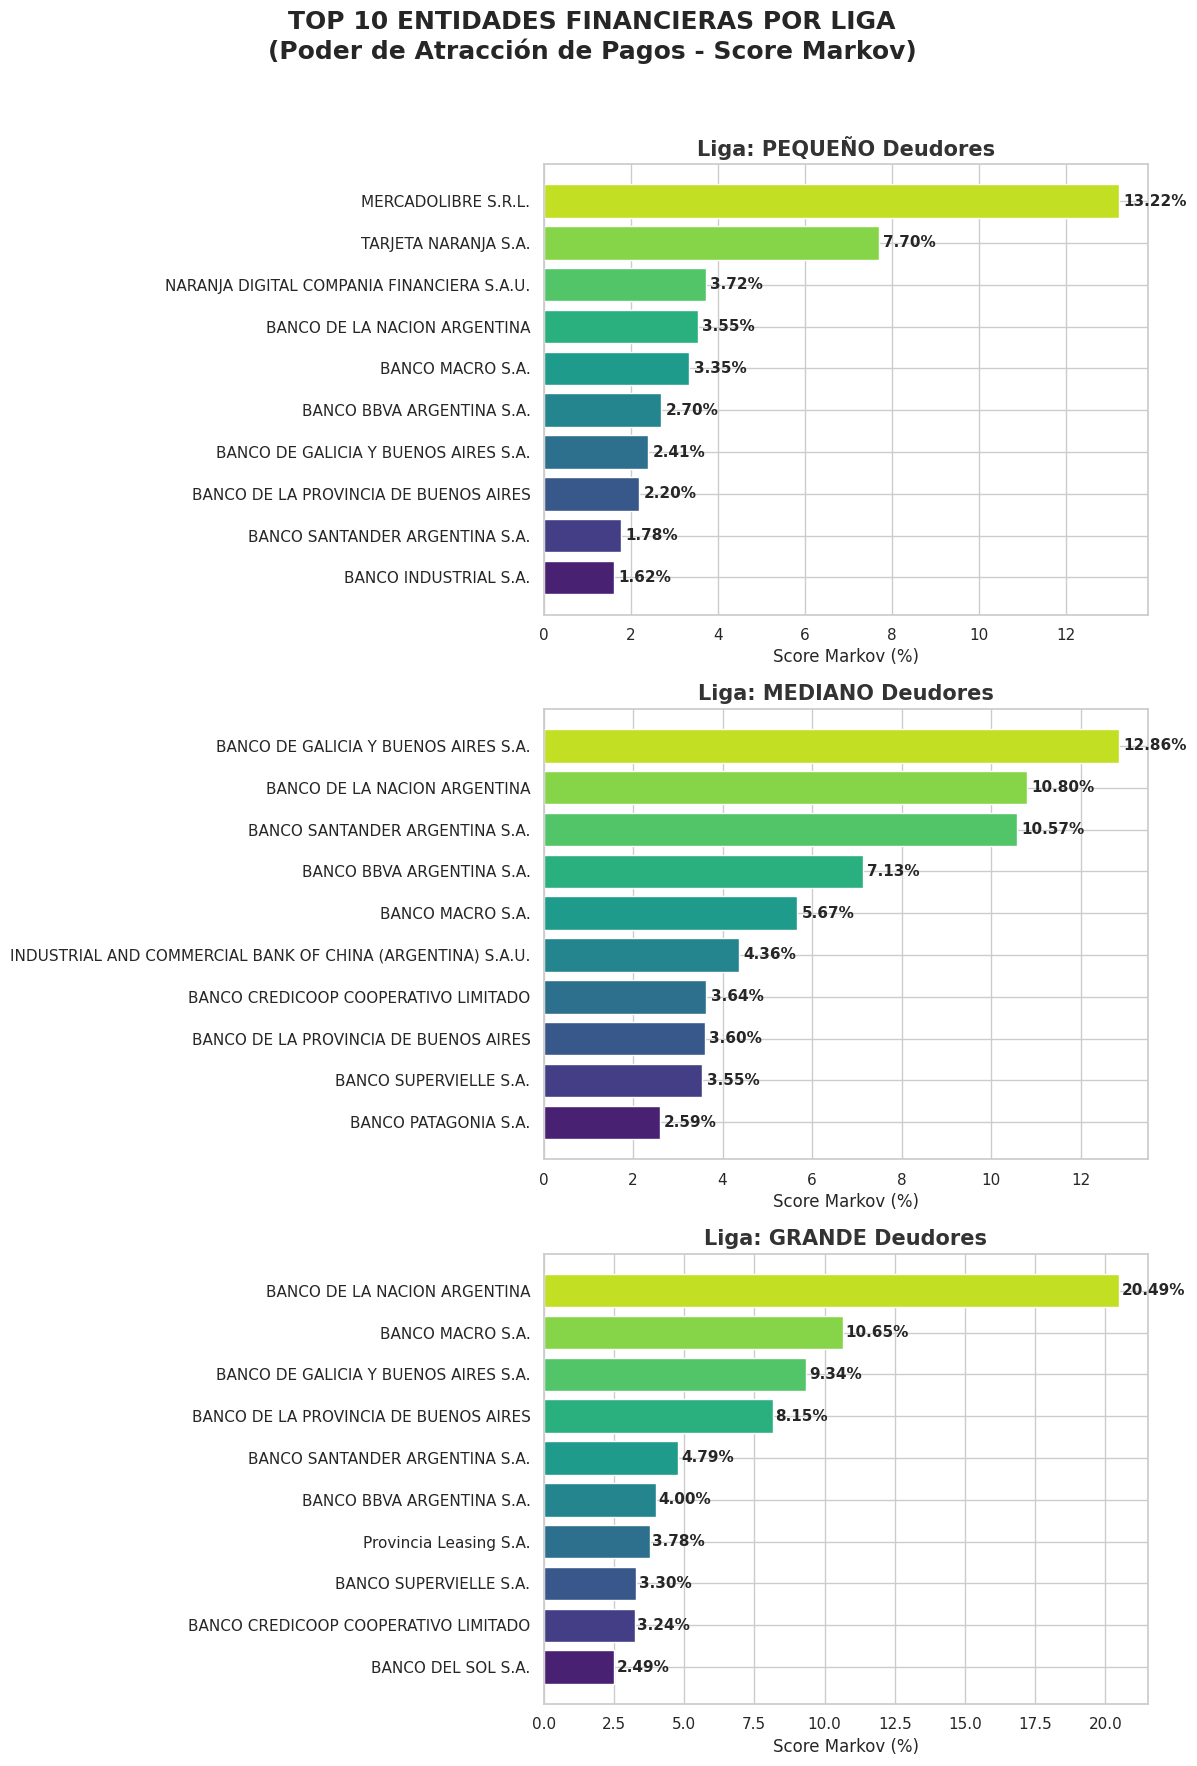


¡GRÁFICOS GENERADOS! Guardados en: /content/drive/MyDrive/Tesis2026/clasificacion_output/visualizacion_top10_markov.png


In [5]:
"""
ETAPA D: ENRIQUECIMIENTO DE RANKINGS Y VISUALIZACIÓN
====================================================
1. Carga el catálogo de entidades del BCRA.
2. Cruza (Join) los nombres y grupos con los rankings de Markov generados.
3. Exporta los rankings finales con nombres legibles.
4. Grafica el Top 10 de cada liga para visualizar los resultados de la tesis.
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# --- RUTAS DE ARCHIVOS ---
OUTPUT_DIR = Path("/content/drive/MyDrive/Tesis2026/clasificacion_output")
ENTIDADES_CSV_PATH = "/content/drive/MyDrive/Tesis2026/EntidadesFinancierasBCRA.csv"

def enriquecer_y_graficar():
    print("="*60)
    print("1. CARGANDO CATÁLOGO DE ENTIDADES DEL BCRA")
    print("="*60)

    # MUY IMPORTANTE: Leer el código de entidad como texto para no perder los ceros a la izquierda
    df_entidades = pd.read_csv(ENTIDADES_CSV_PATH, dtype={'cod_entidad': str})
    print(f"Catálogo cargado: {len(df_entidades)} entidades financieras registradas.")

    ligas = ["pequeño", "mediano", "grande"]

    # Configuración general de la visualización
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))
    fig.suptitle("TOP 10 ENTIDADES FINANCIERAS POR LIGA\n(Poder de Atracción de Pagos - Score Markov)",
                 fontsize=18, fontweight='bold', y=0.98)

    for i, liga in enumerate(ligas):
        csv_path = OUTPUT_DIR / f"ranking_markov_{liga}.csv"

        if not csv_path.exists():
            print(f"\n[!] No se encontró el archivo {csv_path}. Saltando liga...")
            continue

        # 1. Cargar el ranking
        # Aseguramos que el código se lea como string para que el join funcione perfecto
        df_ranking = pd.read_csv(csv_path, dtype={'cod_entidad': str})

        # 2. El Join (Cruce)
        # Usamos LEFT JOIN para que si una entidad de Enero no está en el catálogo, no desaparezca del ranking
        df_enrich = pd.merge(df_ranking, df_entidades, on='cod_entidad', how='left')

        # Llenamos nulos por si hay códigos nuevos o dados de baja
        df_enrich['nombre_entidad'] = df_enrich['nombre_entidad'].fillna('Entidad Desc. (' + df_enrich['cod_entidad'] + ')')
        df_enrich['grupo_entidad'] = df_enrich['grupo_entidad'].fillna('Sin Clasificar')

        # Limpieza de columnas residuales (como Unnamed: 0 que deja el to_csv anterior)
        if 'Unnamed: 0' in df_enrich.columns:
            df_enrich = df_enrich.drop(columns=['Unnamed: 0'])

        # Ordenamos las columnas y la tabla
        df_enrich = df_enrich[['cod_entidad', 'nombre_entidad', 'grupo_entidad', 'Score_Markov_pi']]
        df_enrich = df_enrich.sort_values(by='Score_Markov_pi', ascending=False).reset_index(drop=True)
        df_enrich.index += 1 # Puesto 1, 2, 3...

        # 3. Exportar el archivo final para tu documento de tesis
        csv_out_path = OUTPUT_DIR / f"ranking_FINAL_{liga}_enriquecido.csv"
        df_enrich.to_csv(csv_out_path, index=True)

        print(f"\n✓ Liga {liga.upper()} procesada y guardada. TOP 3:")
        print(df_enrich[['nombre_entidad', 'Score_Markov_pi']].head(3).to_string())

        # 4. Armar el Gráfico
        top10 = df_enrich.head(10).copy()

        # Para gráficos de barras horizontales (barh), el primero de la lista queda abajo.
        # Invertimos el orden para que el campeón quede arriba de todo.
        top10 = top10.iloc[::-1]

        ax = axes[i]
        # Multiplicamos por 100 para graficar porcentajes legibles
        bars = ax.barh(top10['nombre_entidad'], top10['Score_Markov_pi'] * 100, color=sns.color_palette("viridis", 10))

        ax.set_title(f"Liga: {liga.upper()} Deudores", fontsize=15, fontweight='bold', color="#333333")
        ax.set_xlabel('Score Markov (%)', fontsize=12)
        ax.set_ylabel('')

        # Etiquetar cada barra con su porcentaje
        for bar in bars:
            width = bar.get_width()
            ax.text(width + 0.1, bar.get_y() + bar.get_height()/2, f'{width:.2f}%',
                    va='center', ha='left', fontsize=11, fontweight='bold')

    # Ajuste de layout para que no se superpongan los nombres largos de los bancos
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    # Guardar gráfico en HD
    grafico_path = OUTPUT_DIR / "visualizacion_top10_markov.png"
    plt.savefig(grafico_path, dpi=200, bbox_inches='tight')
    plt.show()

    print("\n" + "="*60)
    print(f"¡GRÁFICOS GENERADOS! Guardados en: {grafico_path}")
    print("="*60)

if __name__ == "__main__":
    enriquecer_y_graficar()